#  Sample Evaluation Scripts

This Jupyter notebook contains code to evaluate results obtained from FRAM, MRAM, and ReRAM memory modules. The data is retrieved from a database. The notebook enables the evaluation of standard PUF metrics and the generation of visualizations.

> Using the STM32 and ZCU102 setups, we collected more than 50 GB of measurement data. Due to the volume of this dataset, it is not included in this repository. Instead, we provide representative sample data along with pickled measurement files that demonstrate the use of the evaluation scripts.

**Affiliation: University of Passau - Chair of Computer Engineering**

**Author: Florian Frank**

### 1. Install dependencies

> Skip this cell if dependencies are already installed!

In [1]:
!pip install matplotlib
!pip install tikzplotlib
!pip install pandas
!pip install tqdm


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Automatically reload changes in python files

In [2]:
%load_ext autoreload
%autoreload 2

Ensures that several project directories are available on Python’s module search path.

In [8]:
import os
import sys

paths = ["../", "../src",
         "../src/test_scheduling",
         "../src/message_handling",
         "../src/utils"]

for path in paths:
    abs_path = os.path.join(os.getcwd(), path)
    print(f"Add path {abs_path}")
    if abs_path not in sys.path:
        sys.path.insert(0, abs_path)

Add path /Users/florian/Documents/Arbeit/Projekte/pufmem/publications/hardware_x_test_environment/bk/HardwareX_TestInfrastructure/software/experiment_scheduler/evaluation/../
Add path /Users/florian/Documents/Arbeit/Projekte/pufmem/publications/hardware_x_test_environment/bk/HardwareX_TestInfrastructure/software/experiment_scheduler/evaluation/../src
Add path /Users/florian/Documents/Arbeit/Projekte/pufmem/publications/hardware_x_test_environment/bk/HardwareX_TestInfrastructure/software/experiment_scheduler/evaluation/../src/test_scheduling
Add path /Users/florian/Documents/Arbeit/Projekte/pufmem/publications/hardware_x_test_environment/bk/HardwareX_TestInfrastructure/software/experiment_scheduler/evaluation/../src/message_handling
Add path /Users/florian/Documents/Arbeit/Projekte/pufmem/publications/hardware_x_test_environment/bk/HardwareX_TestInfrastructure/software/experiment_scheduler/evaluation/../src/utils


## 2. Timing Analysis of Control Writes of Test Platforms

This section presents an evaluation of the control signal timing for the STM32F429 and ZCU102 test platforms. These measurements were gathered using a [Keysight InfiniiVision 3000A X-Series Oscilloscope.](https://www.keysight.com/de/de/products/oscilloscopes/infiniivision-2-4-channel-digital-oscilloscopes/infiniivision-3000a-x-series-oscilloscopes.html)

### 2.1 Measurement Results STM32F429

The data was collected by gradually reducing `tDSWrite`. For each timing value, 5,000 measurements were recorded.

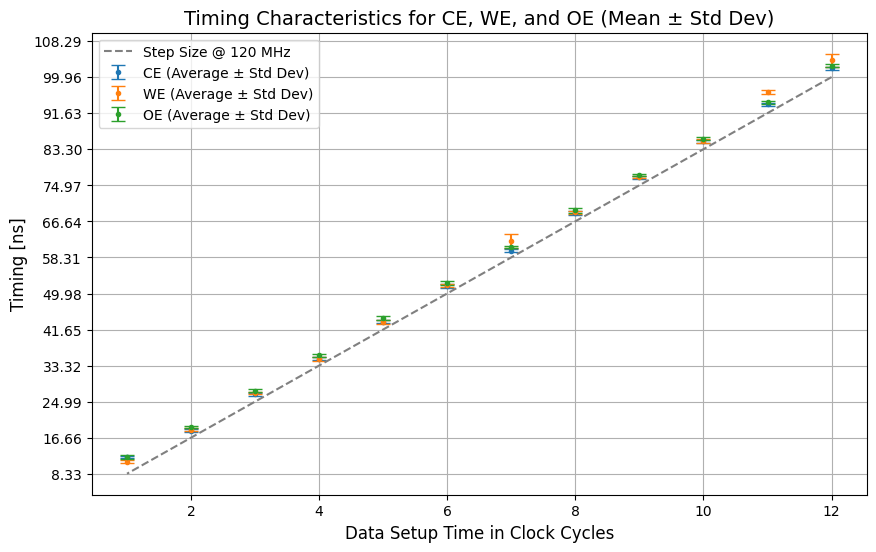

In [9]:
from platform_timing import plot_platform_timing

plot_platform_timing('../output_results/platform_timing/stm32f429_timing.csv', 'stm32f429', 120)

### 2.2 Measurement Results ZCU102

These measurements were collected at a clock frequency of 400 MHz while gradually reducing the timing specification, specifically the parameter tPDWWrite. An overhead remains due to the level shifters, which introduce a delay of approximately 2.39 ns. In addition, at least two extra clock cycles are required by the memory controller’s state machine. For further details, please refer to the documentation of the FPGA design.

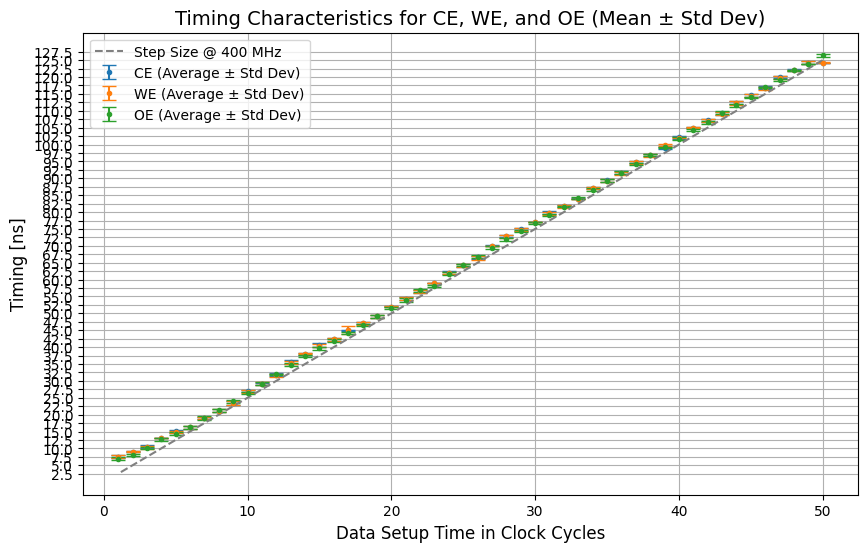

In [10]:
plot_platform_timing('../output_results/platform_timing/zcu102_timing.csv', 'zcu102', 400)

## 3. Examples of memory evaluations

This section presented several examples of how PUF measurements can be evaluated. The total amount of measurement data collected using the ZCU102 and STM32F429 exceeds 50 GB, which cannot be included in a repository. For this reason, a subset of the data is provided as pickled files.

### 3.1 Timing Violations

This section contains all results corresponding to timing violation measurements

#### 3.1.1 Analysis of write Timing Violation Measurements

The following cell presents a table containing all write-timing-violation measurements with modified `tPWD` in the database and evaluates the ratio of bit flips (i.e., deviations from the expected pufValue) for each timing setting. Only results collected from the STM32F429 are included here. 

Here for all repeated measurements the median is calculated and only measurements with a PUF value of 0xaaa are selected.

The second cell visualizes the results as bar-chart.

In [11]:
import test_defines
from evaluation_scripts import evaluate_latency_test
from evaluation.utils import create_panda_table, pickle_results, load_data_if_pickled


write_latency_twd_aa_median = load_data_if_pickled('write_latency_twd_aa_median_stm32')
if not write_latency_twd_aa_median:
    write_latency_twd_aa_median = evaluate_latency_test(test_defines.TestType.WRITE_LATENCY, 'tPWDWrite', 0xaaaa, 'median', "stm32")
    print("Pickle Files")
    pickle_results(data_to_pickle=write_latency_twd_aa_median, file_name='write_latency_twd_aa_median_stm32')
else:
    print("Already pickled file was loaded")

ret = create_panda_table(write_latency_twd_aa_median)
ret

Already pickled file was loaded


,memoryLabels,instanceIDs,119.32 (median),110.52 (median),103.86 (median),96.54 (median),85.16 (median),76.95 (median),68.73 (median),62.11 (median),51.86 (median),43.42 (median),34.89 (median),27.0 (median),18.54 (median),11.07 (median),119.32 (std),110.52 (std),103.86 (std),96.54 (std),85.16 (std),76.95 (std),68.73 (std),62.11 (std),51.86 (std),43.42 (std),34.89 (std),27.0 (std),18.54 (std),11.07 (std)
0,FRAM R5,2,-1,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,-1,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,FRAM R7,3,-1,-1.000000,-1.000000,-1.000000,-1.000000,13.171789,13.135166,13.183996,99.987793,99.987793,99.987793,99.987793,99.987793,99.987793,-1,-1.000000,-1.000000,-1.000000,-1.000000,0.414728,0.408392,0.395791,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,FeFJ1,14,-1,0.016785,0.014496,0.014496,0.013733,0.014496,32.124764,49.948501,49.960804,49.967766,50.021553,-1.000000,-1.000000,-1.000000,-1,0.003714,0.003603,0.003255,0.003799,0.003164,1.104356,0.021957,0.014821,0.012236,0.049226,-1.000000,-1.000000,-1.000000
3,FeFJ2,15,-1,0.009155,0.023651,0.008392,0.003815,0.006104,12.808897,51.723207,51.982990,52.053467,53.344561,-1.000000,-1.000000,-1.000000,-1,6.896564,7.440066,1.602314,1.589120,4.763155,6.367696,0.353951,0.350319,0.254899,0.487433,-1.000000,-1.000000,-1.000000
4,FeFJ3,16,-1,0.000000,0.000000,0.000000,0.000000,0.000000,46.721624,50.000000,50.000000,50.000000,50.000000,-1.000000,-1.000000,-1.000000,-1,0.019623,0.958124,0.000000,0.000000,0.000000,3.338095,0.000000,0.003115,0.000000,19.517223,-1.000000,-1.000000,-1.000000
5,FeFJ4,17,-1,0.044251,0.041962,0.041962,0.043488,0.041962,33.094945,50.728803,50.779825,50.755602,52.809164,-1.000000,-1.000000,-1.000000,-1,0.004200,0.003562,0.003521,0.003080,0.003164,0.725796,0.477954,0.511021,0.503109,1.039660,-1.000000,-1.000000,-1.000000
6,FeFJ5,18,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,49.780749,49.875163,49.896907,49.906444,-1.000000,-1.000000,-1.000000,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.064768,0.032482,0.024576,0.024041,-1.000000,-1.000000,-1.000000
7,FeFJ6,19,-1,0.036621,0.035858,0.034333,0.035095,0.035095,33.228365,50.054551,50.095940,50.082875,50.783640,-1.000000,-1.000000,-1.000000,-1,0.016283,0.002782,0.002565,0.002250,0.015669,2.499042,0.072697,0.091239,0.094557,0.137652,-1.000000,-1.000000,-1.000000
8,FeLa1,4,-1,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.000000,-1,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.562410
9,FeLa10,13,-1,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.000000,-1,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


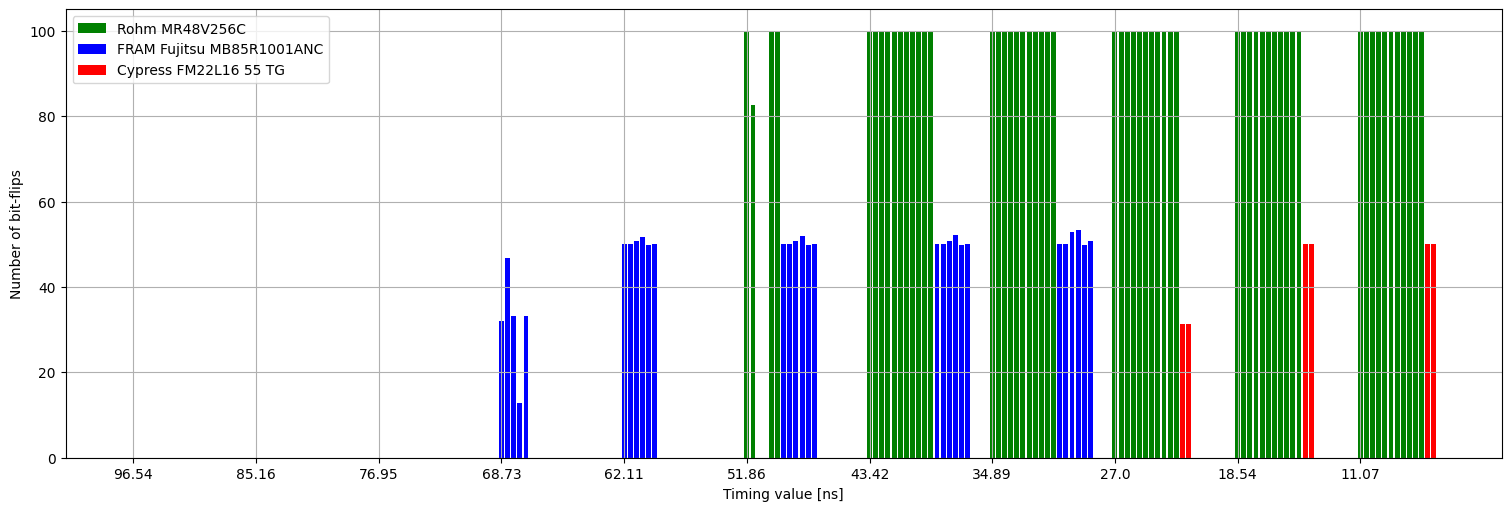

In [13]:
from visualization import plot_timing_bit_flips

plot_timing_bit_flips(write_latency_twd_aa_median, "write_latency_twd_aa_median_stm32")

Measurements on the Rohm MR48V256C memory device were conducted using the ZCU102 evaluation platform. Here the full range down to 43.42 ns is analyzed with higher precision. The ZCU102 supports write timing in 2.5 ns steps (400 MHz), providing a significantly higher precision then the STM32 based test system (120 MHz).

In [14]:
import test_defines
from evaluation_scripts import evaluate_latency_test
from evaluation.utils import pickle_results, load_data_if_pickled


write_latency_rohm_full_tds_aa_median_zcu102 = load_data_if_pickled('write_latency_rohm_full_tds_aa_median_zcu102')
if not write_latency_rohm_full_tds_aa_median_zcu102:
    write_latency_rohm_full_tds_aa_median_zcu102 = evaluate_latency_test(test_defines.TestType.WRITE_LATENCY, 'tDSWrite', 0xaaaa, 'median')
    print("Pickle Files")
    pickle_results(data_to_pickle=write_latency_rohm_full_tds_aa_median_zcu102, file_name='write_latency_rohm_full_tds_aa_median_zcu102')
else:
    print("Already pickled file was loaded")

Already pickled file was loaded


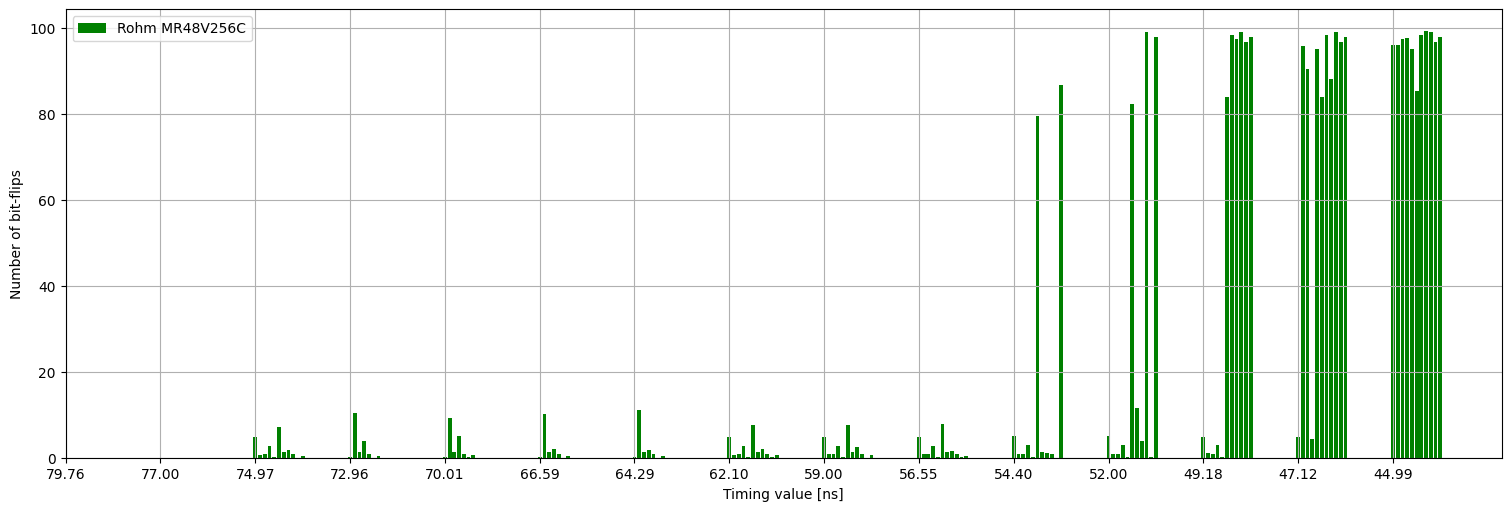

In [15]:
from visualization import plot_timing_bit_flips

plot_timing_bit_flips(write_latency_rohm_full_tds_aa_median_zcu102, "write_latency_rohm_full_tds_aa_median_zcu102")

Isolation of the critical timing range from 51.86 ns to 43.42 ns was analyzed with higher resolution.

In [17]:
import test_defines
from evaluation_scripts import evaluate_latency_test
from evaluation.utils import pickle_results, load_data_if_pickled


write_latency_rohm_twd_aa_median_zcu102 = load_data_if_pickled('write_latency_rohm_twd_aa_median_zcu102')
if not write_latency_rohm_twd_aa_median_zcu102:
    write_latency_rohm_twd_aa_median_zcu102 = evaluate_latency_test(test_defines.TestType.WRITE_LATENCY, 'tPWDWrite', 0xaaaa, 'median', "zcu102")
    print("Pickle Files")
    pickle_results(data_to_pickle=write_latency_rohm_twd_aa_median_zcu102, file_name='write_latency_rohm_twd_aa_median_zcu102')
else:
    print("Already pickled file was loaded")

Already pickled file was loaded


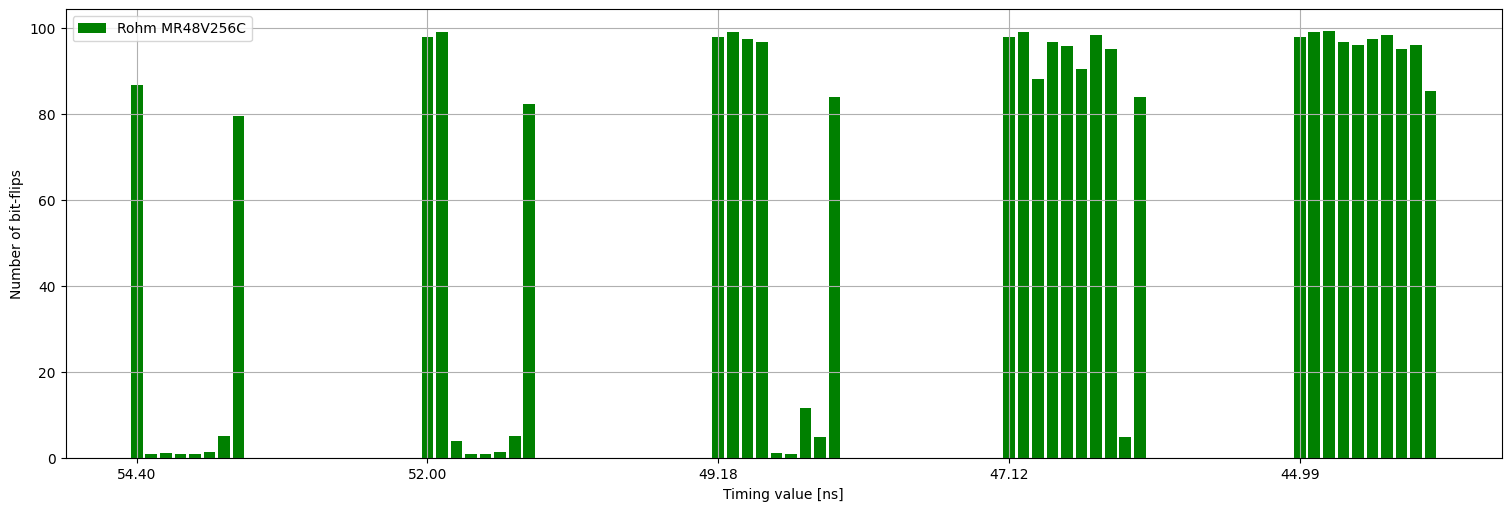

In [18]:
from visualization import plot_timing_bit_flips

plot_timing_bit_flips(write_latency_rohm_twd_aa_median_zcu102, "write_latency_rohm_twd_aa_median_zcu102")

#### 3.1.2 Analysis of Read Timing Violation Measurements

The following cell presents a table containing all read-timing-violation measurements with modified `tPRC` in the database and evaluates the ratio of bit flips (deviations from the expected pufValue) for each timing setting. Only results collected from the STM32F429 are included here. 

Here for all repeated measurements the median is calculated and only measurements with a PUF value of 0xaaa are selected.

In [19]:
from evaluation_scripts import evaluate_latency_test
import test_defines
from evaluation.utils import create_panda_table, pickle_results, load_data_if_pickled

read_latency_trc_aa_median_stm32 = load_data_if_pickled('read_latency_trc_aa_median_stm32')
if not read_latency_trc_aa_median_stm32:
    print("Load and pickle data")
    read_latency_trc_aa_median_stm32 = evaluate_latency_test(test_defines.TestType.READ_LATENCY, 'tPRC', 0xaaaa, 'median', "stm32")
    print("Pickle Files")
    pickle_results(data_to_pickle=read_latency_checker_aa, file_name='latency_checker_aa')
else:
    print("Already pickled file was loaded")

Already pickled file was loaded


In [20]:
ret = create_panda_table(read_latency_trc_aa_median_stm32)
ret

,memoryLabels,instanceIDs,119.32 (median),110.52 (median),103.86 (median),96.54 (median),85.16 (median),76.95 (median),68.73 (median),62.11 (median),51.86 (median),43.42 (median),34.89 (median),27.0 (median),18.54 (median),11.07 (median),119.32 (std),110.52 (std),103.86 (std),96.54 (std),85.16 (std),76.95 (std),68.73 (std),62.11 (std),51.86 (std),43.42 (std),34.89 (std),27.0 (std),18.54 (std),11.07 (std)
0,FRAM R5,2,-1,-1.000000,-1.0,-1.0,0.000000,0.000000,0.000000,0.00000,50.000000,50.0,50.0,50.000000,50.0,-1,-1,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,-1
1,FRAM R7,3,-1,-1.000000,-1.0,-1.0,0.000000,0.866726,50.000000,50.00000,50.000000,50.0,50.0,50.000000,50.0,-1,-1,-1.000000,-1.000000,-1.000000,0.000000,0.063432,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,-1
2,FeFJ1,14,-1,0.000000,0.0,0.0,0.000000,50.000000,50.000000,50.00000,50.000000,50.0,-1.0,-1.000000,-1.0,-1,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-1.000000,-1.0,-1.0,-1
3,FeFJ2,15,-1,0.000000,0.0,0.0,0.000000,50.000000,50.000000,50.00000,50.000000,50.0,-1.0,-1.000000,-1.0,-1,-1,0.000000,0.000000,0.000000,0.000000,0.000000,18.911153,0.000000,0.000000,0.0,-1.000000,-1.0,-1.0,-1
4,FeFJ3,16,-1,0.000048,0.0,0.0,0.000811,50.000000,50.000000,50.00000,50.000000,50.0,-1.0,-1.000000,-1.0,-1,-1,0.010064,0.001557,0.000156,0.004773,0.000000,0.000000,0.000000,0.000000,0.0,-1.000000,-1.0,-1.0,-1
5,FeFJ4,17,-1,0.000000,0.0,0.0,0.000000,50.000000,50.000000,50.00000,50.000000,50.0,-1.0,-1.000000,-1.0,-1,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-1.000000,-1.0,-1.0,-1
6,FeFJ5,18,-1,0.000000,0.0,0.0,0.000000,50.000000,50.000000,50.00000,50.000000,50.0,-1.0,-1.000000,-1.0,-1,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-1.000000,-1.0,-1.0,-1
7,FeFJ6,19,-1,0.000000,0.0,0.0,0.000000,50.000000,50.000000,50.00000,50.000000,50.0,-1.0,-1.000000,-1.0,-1,-1,0.000000,0.000000,0.000000,0.000000,7.239059,0.000000,0.000000,0.818538,0.0,-1.000000,-1.0,-1.0,-1
8,FeLa1,4,-1,-1.000000,-1.0,-1.0,0.000000,0.000000,0.000000,0.00000,0.000000,50.0,50.0,50.000000,50.0,-1,-1,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,-1
9,FeLa10,13,-1,-1.000000,-1.0,-1.0,0.000000,0.000000,0.000000,0.00000,0.000000,50.0,50.0,50.000000,50.0,-1,-1,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,-1


Creates a boxplot of the previously loaded data.

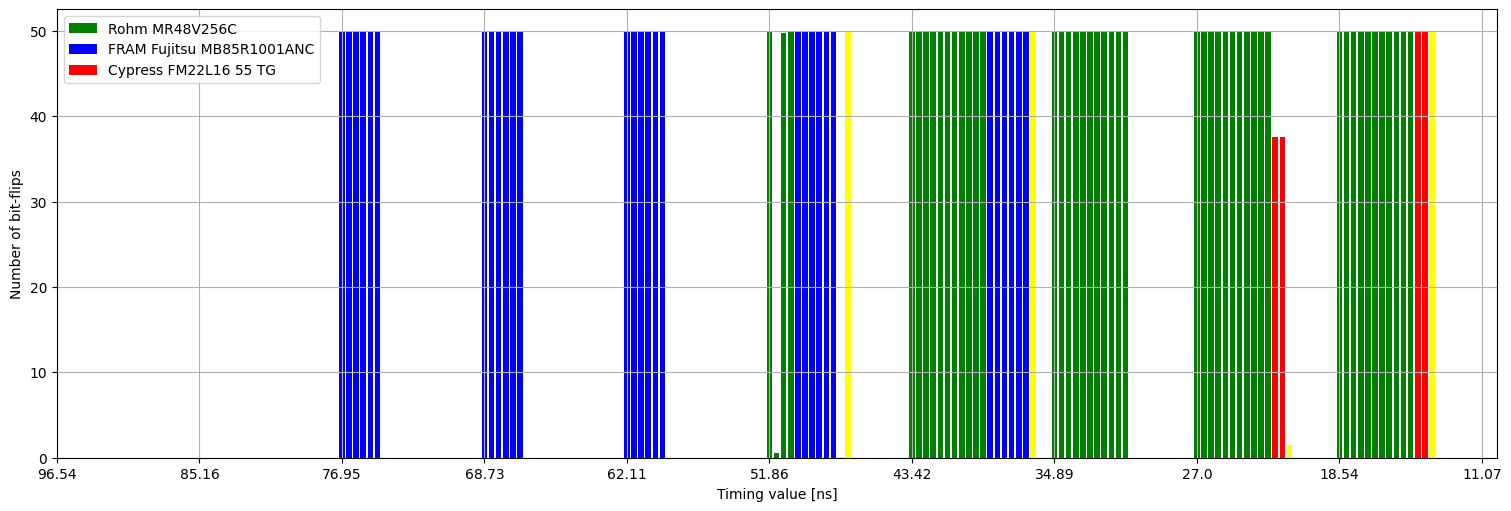

In [21]:
from visualization import plot_timing_bit_flips

plot_timing_bit_flips(read_latency_trc_aa_median_stm32, "read_latency_trc_aa_median_stm32")

In [22]:
from typing import List
from itertools import combinations
import statistics
import numpy as np
import matplotlib.pyplot as plt

import test_defines
from evaluation_scripts import evaluate_inter_hamming_distance, evaluate_intra_hamming_distance


def calculate_bit_diff_list(mem_module: str,
                            experiment: test_defines.TestType,
                            param: str,
                            puf_val: int,
                            reduction_val: int) -> List:
    """
    Computes the intra-Hamming distances for all instances of the given memory module.

    Args:
        mem_module (str): Memory type identifier (e.g., SRAM, ReRAM).
        experiment (TestType): Type of the test (from test_defines).
        param (str): Parameter to be passed to the evaluation function.
        puf_val (int): Number of evaluations per PUF instance.
        reduction_val (int): Reduction parameter (e.g., bitmasking or dimensionality reduction level).

    Returns:
        List: A list of intra-Hamming distance results (each result may be a list).
    """
    identifiers = get_all_instances_of_type(mem_module)
    bit_difference_list = []

    for identifier in identifiers:
        res = evaluate_intra_hamming_distance(experiment, identifier, puf_val, param, reduction_val)
        if res:  # Only append non-empty results
            bit_difference_list.append(res)

    return bit_difference_list


def calculate_uniqueness_list(memory_type: str,
                              test_type: test_defines.TestType,
                              puf_value: int,
                              param: str,
                              reduction_amount: int) -> List:
    """
    Computes the inter-Hamming distances between all pairs of instances of the given memory module.

    Args:
        memory_type (str): Type of memory to evaluate.
        test_type (TestType): Type of the test (from test_defines).
        puf_value (int): Number of evaluations per PUF instance.
        param (str): Parameter for the evaluation.
        reduction_amount (int): Bit reduction parameter.

    Returns:
        List: A list of inter-Hamming distances (each result may be a list).
    """
    identifiers = get_all_instances_of_type(memory_type)
    bit_difference_list_uniqueness = []

    for id1, id2 in combinations(identifiers, 2):
        diff = evaluate_inter_hamming_distance(test_type, id1, id2, puf_value, param, reduction_amount)
        if diff:  # Only append non-empty results
            bit_difference_list_uniqueness.append(diff)

    return bit_difference_list_uniqueness


def plot_histogram_uniqueness(diff_list: List):
    """
    Flattens and plots a histogram of inter-Hamming distances from a nested list.

    Args:
        diff_list (List): A nested list containing lists of inter-Hamming distances.
    """
    # Flatten the nested list
    flat_list = [item for sublist in diff_list for item in sublist]
    flat_array = np.array(flat_list)

    # Print values, formatted with line breaks every 10 entries
    for i, x in enumerate(flat_array):
        sep = '\n' if i % 10 == 0 else ' '
      #  print(f'{round(x, 2)}', end=sep)

    # Plot histogram
    plt.hist(flat_array, bins=20, edgecolor='black')
    plt.xlabel("Inter Hamming Distances [\%]")
    plt.ylabel("Frequency of Occurrence")
    plt.grid(True)
    plt.show()

    # Print mean value
    print(f'\nMean Inter Hamming Distance: {round(statistics.mean(flat_array), 2)}%')


#### Robustness analysis FRAM_Fujitsu_MB85R1001ANC_GE1

In this example measurements of a [RAMAXEED MB85R1001 (former Fujitsu)](https://www.mouser.de/datasheet/3/3800/1/MB85R1001A-DS6v1-E.pdf) are loaded and the intra hamming distance is calculated for each read latency measurement with the `prc`timing value reduced by 20. The mapping of timing value for the ZCU102 and STM32F429 can be found within the `utils.py` file in the evaluation folder.

The second cell visualizes a boxplot with the Meausred FRAM modules.



In [25]:


fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20 = load_data_if_pickled('FRAM_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20')
if not fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20:
    fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20 = calculate_bit_diff_list('FRAM_Fujitsu_MB85R1001ANC_GE1', test_defines.TestType.WRITE_LATENCY, 'tPWDWrite', 0xaaaa, -20)
    print("Pickle Files")
    pickle_results(data_to_pickle=fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20, file_name='fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20')
else:
    print("Already pickled file was loaded")

Already pickled file was loaded


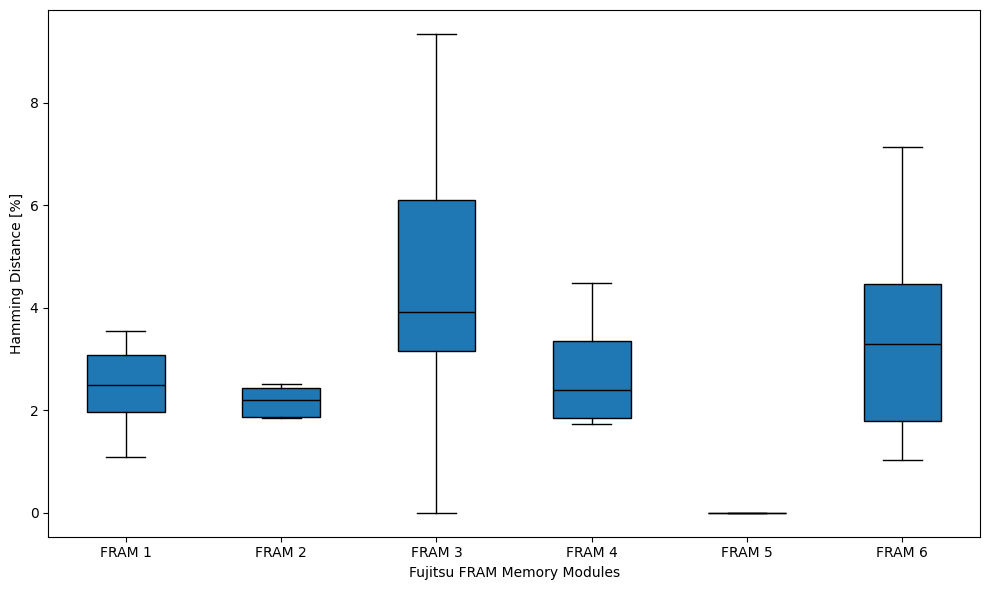

In [26]:
# calculate_box_plot_data(diff_list_fram_write_0xaa) Plot data allowing inclusion as tikz figure
from visualization import plot_multiple_box_plots
plot_multiple_box_plots(fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20, 'robustness_fram_fujitsu', [f'FRAM {i+1}' for i in range(len(fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20))], 'Fujitsu FRAM Memory Modules', 'Hamming Distance [%]')

In [27]:


fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20 = load_data_if_pickled('FRAM_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20')
if not fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20:
    fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20 = calculate_bit_diff_list('FRAM_Fujitsu_MB85R1001ANC_GE1', test_defines.TestType.WRITE_LATENCY, 'tPWDWrite', 0xaaaa, -20)
    print("Pickle Files")
    pickle_results(data_to_pickle=fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20, file_name='fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_20')
else:
    print("Already pickled file was loaded")

Already pickled file was loaded


The subsequent cell calculates the uniqueness values across different Fujitsu_MB85R1001ANC modules, with tPWDWrite reduced by 20 clock counts based on the STM32’s timing.

In [30]:
fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_uniqueness = load_data_if_pickled('fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_uniqueness')
if not fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_uniqueness:
    fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_uniqueness = calculate_uniqueness_list('FRAM_Fujitsu_MB85R1001ANC_GE1', test_defines.TestType.WRITE_LATENCY, 0xaaaa, 'tPWDWrite', -20)
    print("Pickle Files")
    pickle_results(data_to_pickle=fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_uniqueness, file_name='fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_uniqueness')
else:
    print("Already pickled file was loaded")

Already pickled file was loaded


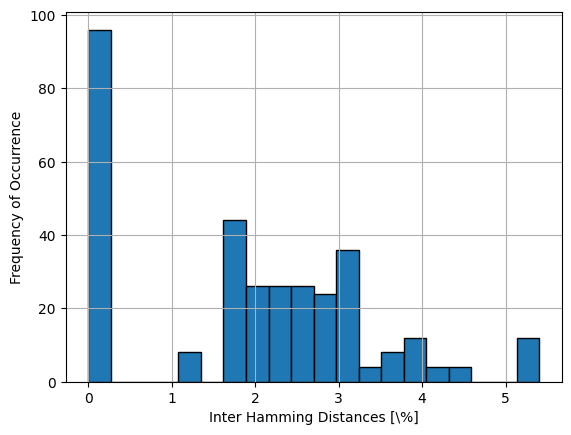


Mean Inter Hamming Distance: 1.92%


In [31]:
plot_histogram_uniqueness(fram_Fujitsu_MB85R1001ANC_GE1_write_latency_twd_0xaa_uniqueness)

### 3.2 Voltage Variations

This section presents evaluation results from experiments conducted under varying voltage conditions. Most measurements were collected using SPD1305X.py–controlled power supplies. For higher precision, the implementation can additionally utilize Keithley KEI2600 SMUs provided through the instrument control library.

#### 3.2.1 Voltage Variations During Read Operations

In this section, voltage variations are applied during read operations, while write operations are performed using the voltage levels specified in the memory device’s manual.


In [32]:
from evaluation_scripts import evaluate_voltage_test
import test_defines
from evaluation.utils import create_panda_table, pickle_results, load_data_if_pickled

voltage_read_0xaa = load_data_if_pickled('voltage_read_0xaa')
if not voltage_read_0xaa:
    print("Load and pickle data")
    voltage_read_0xaa = evaluate_voltage_test(test_defines.TestType.VOLTAGE_READ, 'voltage_change', 0xaaaa, 'median')
    print("Pickle Files")
    pickle_results(data_to_pickle=voltage_read_0xaa, file_name='voltage_read_0xaa')
else:
    print("Already pickled file was loaded")

Already pickled file was loaded


In [33]:
ret = create_panda_table(voltage_read_0xaa)
ret

,memoryLabels,instanceIDs,3.0 (median),2.9 (median),2.8 (median),2.7 (median),2.6 (median),2.5 (median),2.4 (median),2.3 (median),2.2 (median),2.1 (median),2.0 (median),1.9 (median),1.8 (median),1.7 (median),1.6 (median),1.5 (median),1.4 (median),1.3 (median),1.2 (median),1.1 (median),1.0 (median),0.9 (median),0.8 (median),0.7 (median),0.6 (median),0.5 (median),0.4 (median),0.3 (median),0.2 (median),0.1 (median),3.0 (std),2.9 (std),2.8 (std),2.7 (std),2.6 (std),2.5 (std),2.4 (std),2.3 (std),2.2 (std),2.1 (std),2.0 (std),1.9 (std),1.8 (std),1.7 (std),1.6 (std),1.5 (std),1.4 (std),1.3 (std),1.2 (std),1.1 (std),1.0 (std),0.9 (std),0.8 (std),0.7 (std),0.6 (std),0.5 (std),0.4 (std),0.3 (std),0.2 (std),0.1 (std)
0,FRAM R5,2,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,FRAM R7,3,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,FeFJ1,14,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,FeFJ2,15,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,FeFJ3,16,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,FeFJ4,17,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
6,FeFJ5,18,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
7,FeFJ6,19,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0000

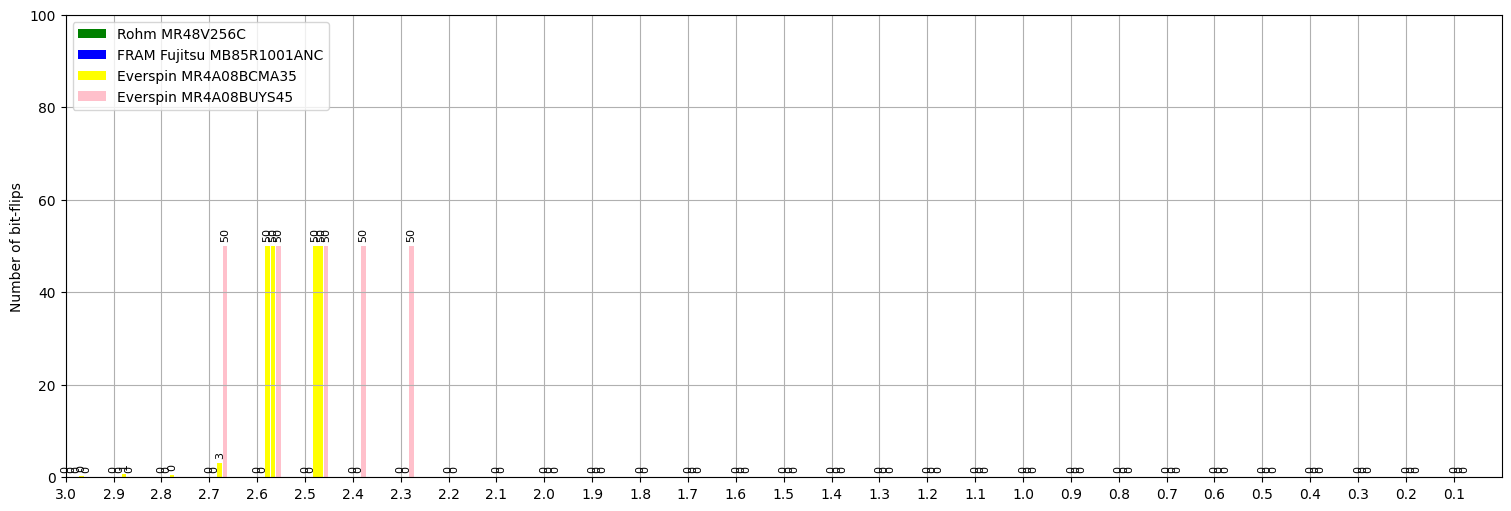

In [35]:
from visualization import plot_timing_bit_flips_voltage

plot_timing_bit_flips_voltage(voltage_read_0xaa, "voltage_read_0xaa", log=False, voltage_range=[0,30], maximum=100)

#### 3.2.2 Voltage Variations During Read Operations

In this section, voltage variations are applied during write operations, while the subsequent read operations is performed using the voltage levels specified in the memory device’s manual.

In [36]:
from evaluation_scripts import evaluate_voltage_test
import test_defines
from evaluation.utils import create_panda_table, pickle_results, load_data_if_pickled

voltage_write_0xaa = load_data_if_pickled('voltage_write_0xaa')
if not voltage_write_0xaa:
    print("Load and pickle data")
    voltage_write_0xaa = evaluate_voltage_test(test_defines.TestType.VOLTAGE_WRITE, 'voltage_change', 0xaaaa, 'median')
    print("Pickle Files")
    pickle_results(data_to_pickle=voltage_write_0xaa, file_name='voltage_write_0xaa')
else:
    print("Already pickled file was loaded")

Already pickled file was loaded


In [37]:
ret = create_panda_table(voltage_write_0xaa)
ret

,memoryLabels,instanceIDs,3.0 (median),2.9 (median),2.8 (median),2.7 (median),2.6 (median),2.5 (median),2.4 (median),2.3 (median),2.2 (median),2.1 (median),2.0 (median),1.9 (median),1.8 (median),1.7 (median),1.6 (median),1.5 (median),1.4 (median),1.3 (median),1.2 (median),1.1 (median),1.0 (median),0.9 (median),0.8 (median),0.7 (median),0.6 (median),0.5 (median),0.4 (median),0.3 (median),0.2 (median),0.1 (median),3.0 (std),2.9 (std),2.8 (std),2.7 (std),2.6 (std),2.5 (std),2.4 (std),2.3 (std),2.2 (std),2.1 (std),2.0 (std),1.9 (std),1.8 (std),1.7 (std),1.6 (std),1.5 (std),1.4 (std),1.3 (std),1.2 (std),1.1 (std),1.0 (std),0.9 (std),0.8 (std),0.7 (std),0.6 (std),0.5 (std),0.4 (std),0.3 (std),0.2 (std),0.1 (std)
0,FRAM R5,2,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,FRAM R7,3,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,FeFJ1,14,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,FeFJ2,15,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000381,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,FeFJ3,16,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,FeFJ4,17,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
6,FeFJ5,18,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
7,FeFJ6,19,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1

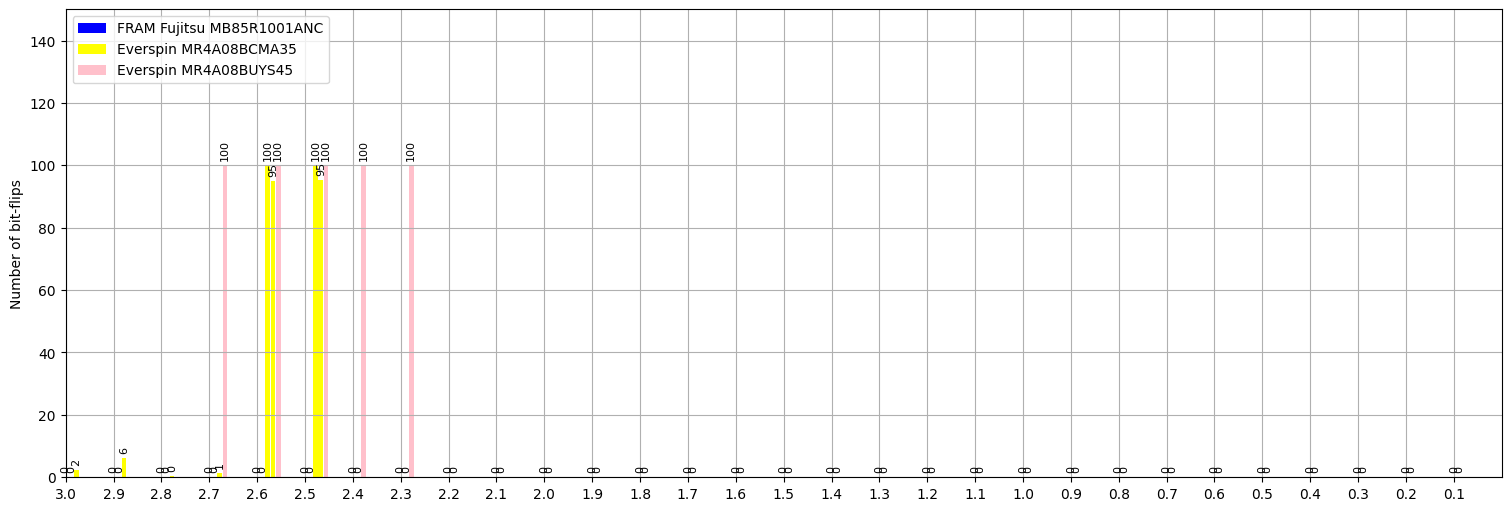

In [38]:
from visualization import plot_timing_bit_flips_voltage


plot_timing_bit_flips_voltage(voltage_write_0xaa, "voltage_write_0xaa", log=False, voltage_range=[0,30], maximum=150)